In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.executable)
print("Pandas:", pd.__version__)

Python: /Users/sid/Documents/coding/datajam-cyberabad/.venv/bin/python
Pandas: 2.3.3


In [2]:
from pathlib import Path
import pandas as pd

# Project paths
PROJECT_ROOT = Path.cwd().parent
HMRL_DIR = PROJECT_ROOT / "Telangana_opendata_gtfs_hmrl_02_September_2026"

# Load GTFS files
agency = pd.read_csv(HMRL_DIR / "agency.txt")
calendar = pd.read_csv(HMRL_DIR / "calendar.txt")
fare_attributes = pd.read_csv(HMRL_DIR / "fare_attributes.txt")
fare_rules = pd.read_csv(HMRL_DIR / "fare_rules.txt")
feed_info = pd.read_csv(HMRL_DIR / "feed_info.txt")
routes = pd.read_csv(HMRL_DIR / "routes.txt")
shapes = pd.read_csv(HMRL_DIR / "shapes.txt")
stop_times = pd.read_csv(HMRL_DIR / "stop_times.txt")
stops = pd.read_csv(HMRL_DIR / "stops.txt")
trips = pd.read_csv(HMRL_DIR / "trips.txt")

print("HMRL GTFS loaded successfully.")

HMRL GTFS loaded successfully.


In [3]:
overview = {
    "Stations": (stops["location_type"] == 1).sum(),
    "All stop records": len(stops),
    "Routes": len(routes),
    "Trips": len(trips),
    "Stop-time records": len(stop_times),
    "Shape points": len(shapes),
}

pd.Series(overview)

Stations                57
All stop records       705
Routes                   3
Trips                 2895
Stop-time records    62759
Shape points          2450
dtype: int64

In [4]:
for name, df in {
    "agency": agency,
    "calendar": calendar,
    "routes": routes,
    "trips": trips,
    "stops": stops,
    "stop_times": stop_times,
    "shapes": shapes,
}.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))


AGENCY
Shape: (1, 8)
Columns: ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_fare_url', 'agency_email', 'agency_phone']

CALENDAR
Shape: (3, 10)
Columns: ['service_id', 'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday', 'start_date', 'end_date']

ROUTES
Shape: (3, 8)
Columns: ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_type', 'route_color', 'route_text_color', 'route_sort_order']

TRIPS
Shape: (2895, 7)
Columns: ['service_id', 'route_id', 'trip_id', 'direction_id', 'trip_headsign', 'block_id', 'shape_id']

STOPS
Shape: (705, 8)
Columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'zone_id', 'location_type', 'parent_station', 'platform_code']

STOP_TIMES
Shape: (62759, 7)
Columns: ['trip_id', 'stop_sequence', 'stop_id', 'arrival_time', 'departure_time', 'timepoint', 'shape_dist_traveled']

SHAPES
Shape: (2450, 5)
Columns: ['shape_id', 'shape_pt_lat', 'shape_pt_lon', 'shape_pt_sequence', 's

In [5]:
routes[
    [
        "route_id",
        "route_short_name",
        "route_long_name",
        "route_type",
    ]
]

,route_id,route_short_name,route_long_name,route_type
0,RED,C1_RED,Miyapur - LB Nagar - Miyapur - C1,1
1,GREEN,C2_GREEN,JBS Parade Ground - MG Bus Station - JBS Parad...,1
2,BLUE,C3_BLUE,Nagole - Raidurg - Nagole - C3,1


In [6]:
trips.groupby(
    ["route_id", "direction_id", "trip_headsign"]
).size().reset_index(name="trips")

,route_id,direction_id,trip_headsign,trips
0,BLUE,0,HITEC City,2
1,BLUE,0,Paradise,2
2,BLUE,0,Peddamma Gudi,2
3,BLUE,0,Raidurg,584
4,BLUE,0,Tarnaka,2
5,BLUE,1,Ameerpet,6
6,BLUE,1,Madhapur,2
7,BLUE,1,Madhura Nagar,8
8,BLUE,1,Mettuguda,13
9,BLUE,1,Nagole,555


In [7]:
stations = (
    stops[stops["location_type"] == 1]
    .copy()
    .reset_index(drop=True)
)

stations[
    [
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
    ]
].head(20)

,stop_id,stop_name,stop_lat,stop_lon
0,MYP,Miyapur,17.496545,78.373026
1,JNT,JNTU College,17.498704,78.388867
2,KPH,KPHB Colony,17.493760,78.401826
3,KUK,Kukatpally,17.484903,78.411790
4,BLR,Balanagar,17.476746,78.422108
5,MSP,Moosapet,17.471885,78.426118
6,BTN,Bharat Nagar,17.462909,78.430536
7,ERA,Erragadda,17.457049,78.433581
8,ESI,ESI Hospital,17.448697,78.437628
9,SRN,S. R. Nagar,17.443120,78.440724


In [8]:
print(f"Metro stations: {len(stations)}")

Metro stations: 57


In [9]:
stops.groupby(
    ["location_type"]
).size()

location_type
0    117
1     57
2    531
dtype: int64

In [10]:
stops["parent_station"].notna().sum()

np.int64(648)

In [11]:
stops[
    stops["parent_station"].notna()
][
    [
        "stop_id",
        "stop_name",
        "parent_station",
        "platform_code",
        "location_type",
    ]
].head(20)

,stop_id,stop_name,parent_station,platform_code,location_type
1,MYP1,Miyapur,MYP,1.0,0
2,MYP2,Miyapur,MYP,2.0,0
4,JNT1,JNTU College,JNT,1.0,0
5,JNT2,JNTU College,JNT,2.0,0
7,KPH1,KPHB Colony,KPH,1.0,0
8,KPH2,KPHB Colony,KPH,2.0,0
10,KUK1,Kukatpally,KUK,1.0,0
11,KUK2,Kukatpally,KUK,2.0,0
13,BLR1,Balanagar,BLR,1.0,0
14,BLR2,Balanagar,BLR,2.0,0


In [12]:
stops["location_type"].value_counts().sort_index()
stations[["stop_id", "stop_name", "stop_lat", "stop_lon"]].to_string(index=False)

'stop_id                  stop_name  stop_lat  stop_lon\n    MYP                    Miyapur 17.496545 78.373026\n    JNT               JNTU College 17.498704 78.388867\n    KPH                KPHB Colony 17.493760 78.401826\n    KUK                 Kukatpally 17.484903 78.411790\n    BLR                  Balanagar 17.476746 78.422108\n    MSP                   Moosapet 17.471885 78.426118\n    BTN               Bharat Nagar 17.462909 78.430536\n    ERA                  Erragadda 17.457049 78.433581\n    ESI               ESI Hospital 17.448697 78.437628\n    SRN                S. R. Nagar 17.443120 78.440724\n    AME                   Ameerpet 17.435721 78.444793\n    PUN                 Panjagutta 17.428936 78.450955\n    IRM                Erra Manzil 17.420229 78.456349\n    KHA                Khairatabad 17.411632 78.460868\n    LKP               Lakdi-ka-pul 17.404043 78.464944\n    ASM                   Assembly 17.397991 78.470880\n    NAM                   Nampally 17.392222 78

In [13]:
# Map each stop to its parent station
stop_station = stops[[
    "stop_id",
    "stop_name",
    "parent_station",
    "location_type"
]].copy()

# For parent stations, the station ID is the stop_id itself
stop_station["station_id"] = stop_station["parent_station"].fillna(
    stop_station["stop_id"]
)

# Add station names
station_names = stations.set_index("stop_id")["stop_name"].to_dict()
stop_station["station_name"] = stop_station["station_id"].map(station_names)

stop_station.head(10)

,stop_id,stop_name,parent_station,location_type,station_id,station_name
0,MYP,Miyapur,NaN,1,MYP,Miyapur
1,MYP1,Miyapur,MYP,0,MYP,Miyapur
2,MYP2,Miyapur,MYP,0,MYP,Miyapur
3,JNT,JNTU College,NaN,1,JNT,JNTU College
4,JNT1,JNTU College,JNT,0,JNT,JNTU College
5,JNT2,JNTU College,JNT,0,JNT,JNTU College
6,KPH,KPHB Colony,NaN,1,KPH,KPHB Colony
7,KPH1,KPHB Colony,KPH,0,KPH,KPHB Colony
8,KPH2,KPHB Colony,KPH,0,KPH,KPHB Colony
9,KUK,Kukatpally,NaN,1,KUK,Kukatpally


In [14]:
trip_stops = (
    stop_times
    .merge(
        trips[[
            "trip_id",
            "route_id",
            "direction_id",
            "trip_headsign",
            "service_id",
            "shape_id"
        ]],
        on="trip_id",
        how="left"
    )
    .merge(
        stop_station[[
            "stop_id",
            "station_id",
            "station_name"
        ]],
        on="stop_id",
        how="left"
    )
)

trip_stops.head()

,trip_id,stop_sequence,stop_id,arrival_time,departure_time,timepoint,shape_dist_traveled,route_id,direction_id,trip_headsign,service_id,shape_id,station_id,station_name
0,SA_103525,1,MYP1,04:38:10,04:38:40,1,0,RED,0,L. B. Nagar,SA,RED1,MYP,Miyapur
1,SA_103525,2,JNT1,04:40:44,04:40:59,1,1749,RED,0,L. B. Nagar,SA,RED1,JNT,JNTU College
2,SA_103525,3,KPH1,04:42:44,04:42:59,1,3243,RED,0,L. B. Nagar,SA,RED1,KPH,KPHB Colony
3,SA_103525,4,KUK1,04:44:46,04:45:01,1,4728,RED,0,L. B. Nagar,SA,RED1,KUK,Kukatpally
4,SA_103525,5,BLR1,04:46:49,04:47:04,1,6157,RED,0,L. B. Nagar,SA,RED1,BLR,Balanagar


In [15]:
print("Rows:", len(trip_stops))
print("Unique trips:", trip_stops["trip_id"].nunique())
print("Unique stations:", trip_stops["station_id"].nunique())
print("Unique routes:", trip_stops["route_id"].nunique())

Rows: 62759
Unique trips: 2895
Unique stations: 57
Unique routes: 3


In [16]:
trip_stops["hour"] = (
    trip_stops["departure_time"]
    .str.split(":")
    .str[0]
    .astype(int)
)

trip_stops[["station_name", "route_id", "direction_id", "departure_time", "hour"]].head()

,station_name,route_id,direction_id,departure_time,hour
0,Miyapur,RED,0,04:38:40,4
1,JNTU College,RED,0,04:40:59,4
2,KPHB Colony,RED,0,04:42:59,4
3,Kukatpally,RED,0,04:45:01,4
4,Balanagar,RED,0,04:47:04,4


In [17]:
station_frequency = (
    trip_stops
    .groupby(
        ["station_id", "station_name", "route_id", "direction_id", "hour"]
    )
    ["trip_id"]
    .nunique()
    .reset_index(name="scheduled_services")
)

station_frequency.head(20)

,station_id,station_name,route_id,direction_id,hour,scheduled_services
0,AME,Ameerpet,BLUE,0,5,10
1,AME,Ameerpet,BLUE,0,6,18
2,AME,Ameerpet,BLUE,0,7,26
3,AME,Ameerpet,BLUE,0,8,37
4,AME,Ameerpet,BLUE,0,9,44
5,AME,Ameerpet,BLUE,0,10,41
6,AME,Ameerpet,BLUE,0,11,33
7,AME,Ameerpet,BLUE,0,12,30
8,AME,Ameerpet,BLUE,0,13,32
9,AME,Ameerpet,BLUE,0,14,32


In [18]:
station_frequency[
    station_frequency["station_name"] == "Miyapur"
].pivot_table(
    index="hour",
    columns=["route_id", "direction_id"],
    values="scheduled_services",
    fill_value=0
)

route_id       RED      
direction_id     0     1
hour                    
4              5.0   0.0
5             11.0   0.0
6             28.0  15.0
7             33.0  21.0
8             38.0  32.0
9             36.0  34.0
10            34.0  36.0
11            33.0  38.0
12            33.0  33.0
13            34.0  33.0
14            33.0  33.0
15            33.0  32.0
16            39.0  35.0
17            37.0  35.0
18            37.0  37.0
19            39.0  37.0
20            31.0  39.0
21            26.0  37.0
22            16.0  27.0
23             9.0  20.0
24             0.0   2.0

In [19]:
station_total = (
    station_frequency
    .groupby(["station_id", "station_name", "hour"])
    ["scheduled_services"]
    .sum()
    .reset_index()
)

station_total.head(20)

,station_id,station_name,hour,scheduled_services
0,AME,Ameerpet,4,2
1,AME,Ameerpet,5,22
2,AME,Ameerpet,6,80
3,AME,Ameerpet,7,103
4,AME,Ameerpet,8,138
5,AME,Ameerpet,9,156
6,AME,Ameerpet,10,153
7,AME,Ameerpet,11,139
8,AME,Ameerpet,12,128
9,AME,Ameerpet,13,129


In [20]:
# Keep only station-level records and sort each trip in travel order
station_stops = (
    trip_stops
    .sort_values(["trip_id", "stop_sequence"])
    .copy()
)

# Create the next stop within each trip
station_stops["next_station"] = station_stops.groupby("trip_id")["station_name"].shift(-1)
station_stops["next_station_id"] = station_stops.groupby("trip_id")["station_id"].shift(-1)
station_stops["next_arrival"] = station_stops.groupby("trip_id")["arrival_time"].shift(-1)

# Keep only records where there is a next station
segments = station_stops[
    station_stops["next_station"].notna()
].copy()

segments[[
    "route_id",
    "direction_id",
    "station_name",
    "next_station",
    "departure_time",
    "next_arrival"
]].head(20)

,route_id,direction_id,station_name,next_station,departure_time,next_arrival
0,RED,0,Miyapur,JNTU College,04:38:40,04:40:44
1,RED,0,JNTU College,KPHB Colony,04:40:59,04:42:44
2,RED,0,KPHB Colony,Kukatpally,04:42:59,04:44:46
3,RED,0,Kukatpally,Balanagar,04:45:01,04:46:49
4,RED,0,Balanagar,Moosapet,04:47:04,04:48:14
5,RED,0,Moosapet,Bharat Nagar,04:48:29,04:49:50
6,RED,0,Bharat Nagar,Erragadda,04:50:05,04:51:21
7,RED,0,Erragadda,ESI Hospital,04:51:36,04:53:09
8,RED,0,ESI Hospital,S. R. Nagar,04:53:24,04:54:36
9,RED,0,S. R. Nagar,Ameerpet,04:54:51,04:56:21


In [21]:
def gtfs_seconds(time_series):
    parts = time_series.str.split(":")
    return (
        parts.str[0].astype(int) * 3600
        + parts.str[1].astype(int) * 60
        + parts.str[2].astype(int)
    )

segments["departure_seconds"] = gtfs_seconds(segments["departure_time"])
segments["arrival_seconds"] = gtfs_seconds(segments["next_arrival"])

segments["travel_minutes"] = (
    segments["arrival_seconds"] - segments["departure_seconds"]
) / 60

segments[[
    "route_id",
    "direction_id",
    "station_name",
    "next_station",
    "travel_minutes"
]].head(20)

,route_id,direction_id,station_name,next_station,travel_minutes
0,RED,0,Miyapur,JNTU College,2.066667
1,RED,0,JNTU College,KPHB Colony,1.750000
2,RED,0,KPHB Colony,Kukatpally,1.783333
3,RED,0,Kukatpally,Balanagar,1.800000
4,RED,0,Balanagar,Moosapet,1.166667
5,RED,0,Moosapet,Bharat Nagar,1.350000
6,RED,0,Bharat Nagar,Erragadda,1.266667
7,RED,0,Erragadda,ESI Hospital,1.550000
8,RED,0,ESI Hospital,S. R. Nagar,1.200000
9,RED,0,S. R. Nagar,Ameerpet,1.500000


In [22]:
segment_summary = (
    segments
    .groupby([
        "route_id",
        "direction_id",
        "station_id",
        "station_name",
        "next_station_id",
        "next_station"
    ])
    ["travel_minutes"]
    .agg(
        trips="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

segment_summary["mean"] = segment_summary["mean"].round(2)
segment_summary["median"] = segment_summary["median"].round(2)

segment_summary.head(20)

,route_id,direction_id,station_id,station_name,next_station_id,next_station,trips,mean,median,min,max
0,BLUE,0,AME,Ameerpet,MUN,Madhura Nagar,586,1.46,1.43,1.433333,1.683333
1,BLUE,0,BEG,Begumpet,AME,Ameerpet,580,2.99,2.93,2.933333,3.600000
2,BLUE,0,DGC,Durgam Cheruvu,HTC,HITEC City,586,1.56,1.53,1.533333,1.783333
3,BLUE,0,HSG,Habsiguda,TAR,Tarnaka,569,2.04,2.02,2.016667,2.350000
4,BLUE,0,HTC,HITEC City,RDG,Raidurg,584,2.67,2.37,2.366667,19.433333
5,BLUE,0,JCP,Jubilee Hills Checkpost,PED,Peddamma Gudi,587,1.34,1.32,1.316667,1.566667
6,BLUE,0,JR5,Road No 5 Jubilee Hills,JCP,Jubilee Hills Checkpost,587,2.24,2.22,2.216667,2.466667
7,BLUE,0,MAD,Madhapur,DGC,Durgam Cheruvu,586,2.44,2.42,2.416667,2.666667
8,BLUE,0,MET,Mettuguda,SEC_E,Secunderabad East,581,2.75,2.72,2.716667,3.216667
9,BLUE,0,MUN,Madhura Nagar,YUG,Yusufguda,586,2.47,2.45,2.450000,2.700000


In [23]:
hourly_service = (
    trip_stops
    .groupby(["route_id", "hour"])["trip_id"]
    .nunique()
    .reset_index(name="scheduled_trips")
)

hourly_service.head()

,route_id,hour,scheduled_trips
0,BLUE,4,4
1,BLUE,5,18
2,BLUE,6,63
3,BLUE,7,84
4,BLUE,8,120


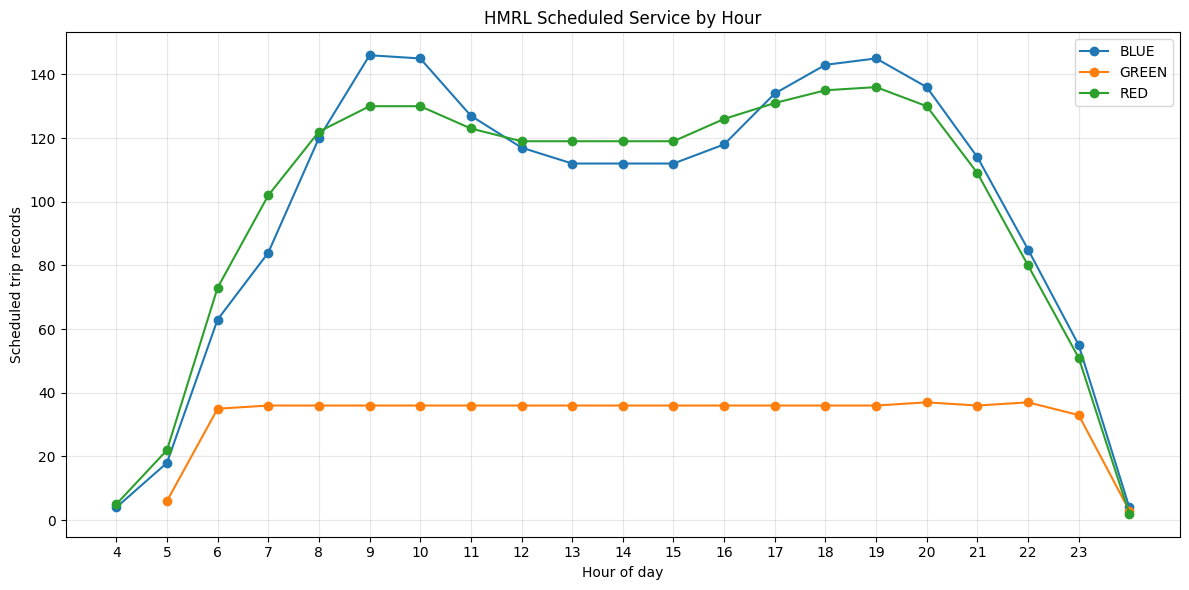

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))

for route in hourly_service["route_id"].unique():
    data = hourly_service[hourly_service["route_id"] == route]
    ax.plot(
        data["hour"],
        data["scheduled_trips"],
        marker="o",
        label=route
    )

ax.set_title("HMRL Scheduled Service by Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Scheduled trip records")
ax.set_xticks(range(4, 24))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

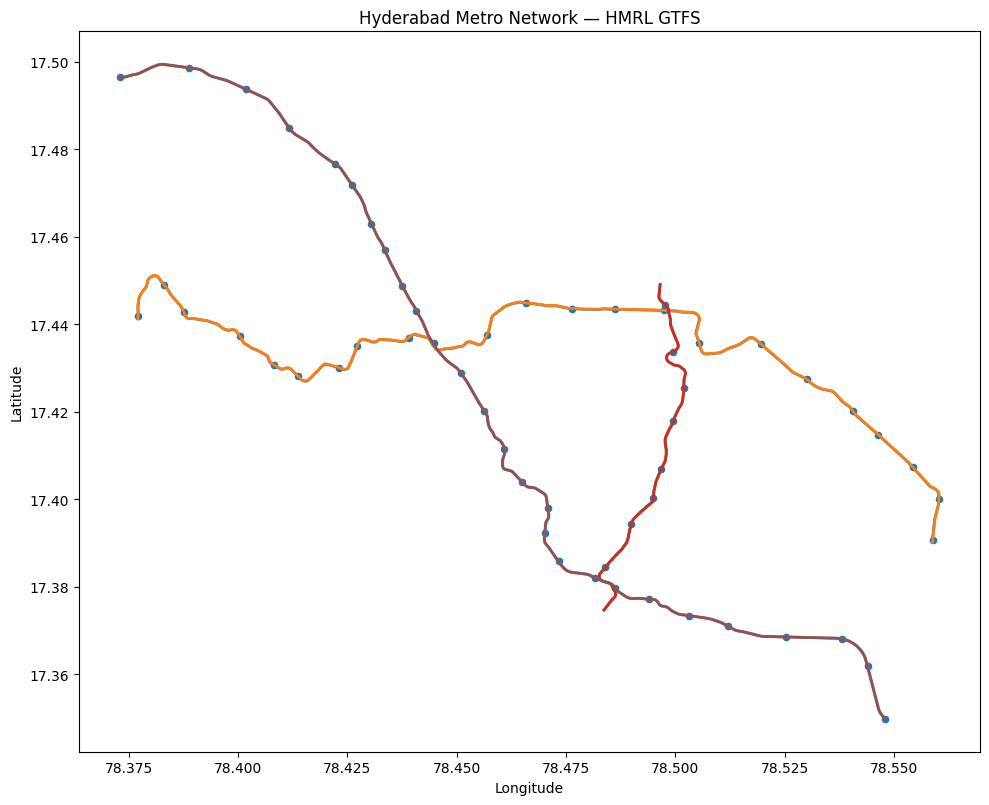

In [25]:
fig, ax = plt.subplots(figsize=(10, 10))

for shape_id, data in shapes.groupby("shape_id"):
    ax.plot(
        data["shape_pt_lon"],
        data["shape_pt_lat"],
        linewidth=2
    )

ax.scatter(
    stations["stop_lon"],
    stations["stop_lat"],
    s=20
)

ax.set_title("Hyderabad Metro Network — HMRL GTFS")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_aspect("equal")

plt.tight_layout()
plt.show()


In [28]:
segment_summary["mean"].describe()

count    112.000000
mean       1.723839
std        0.428434
min        1.140000
25%        1.405000
50%        1.605000
75%        1.912500
max        2.990000
Name: mean, dtype: float64

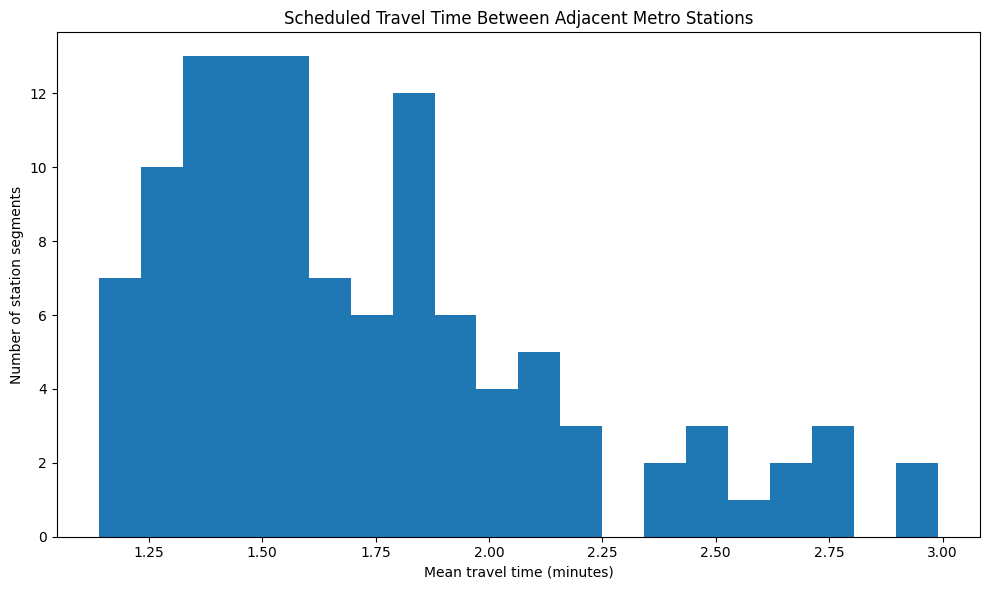

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    segment_summary["mean"],
    bins=20
)

ax.set_title("Scheduled Travel Time Between Adjacent Metro Stations")
ax.set_xlabel("Mean travel time (minutes)")
ax.set_ylabel("Number of station segments")

plt.tight_layout()
plt.show()

In [30]:
segment_summary.columns

Index(['route_id', 'direction_id', 'station_id', 'station_name',
       'next_station_id', 'next_station', 'trips', 'mean', 'median', 'min',
       'max'],
      dtype='object')

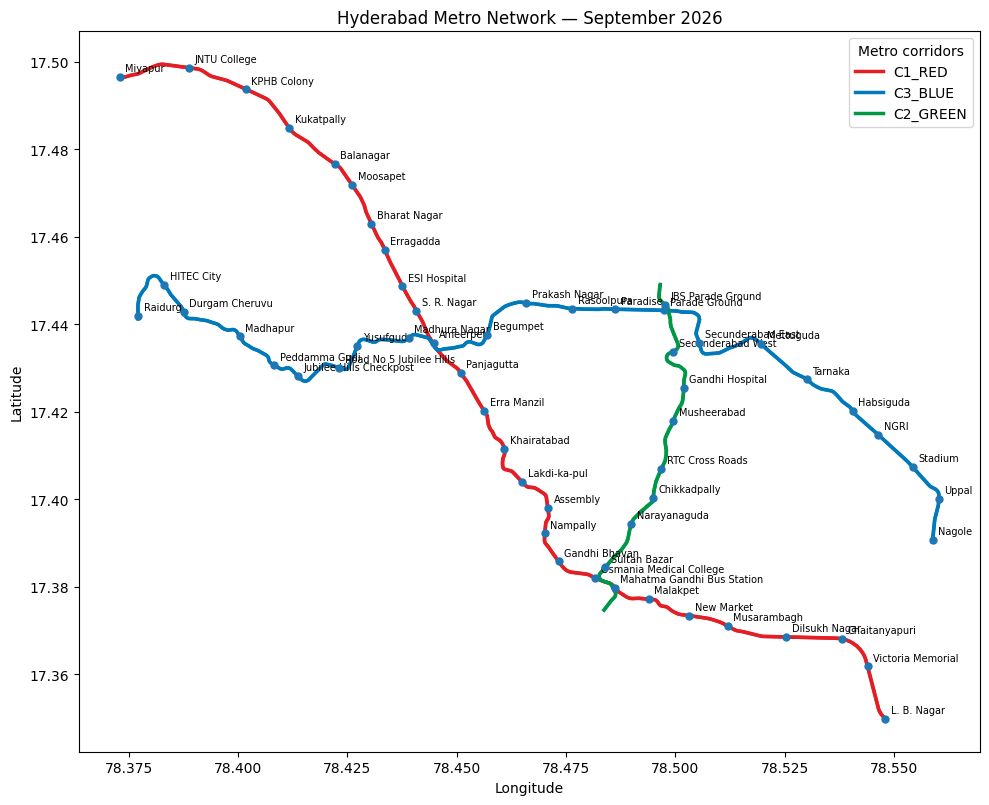

In [32]:
# Connect shapes to their route colors
shape_routes = (
    trips[["route_id", "shape_id"]]
    .drop_duplicates()
    .merge(
        routes[["route_id", "route_color", "route_short_name"]],
        on="route_id",
        how="left"
    )
)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot each shape using the official HMRL route color
for _, sr in shape_routes.iterrows():
    data = shapes[shapes["shape_id"] == sr["shape_id"]].sort_values(
        "shape_pt_sequence"
    )

    color = "#" + sr["route_color"]

    ax.plot(
        data["shape_pt_lon"],
        data["shape_pt_lat"],
        color=color,
        linewidth=2.5,
        label=sr["route_short_name"]
    )

# Plot stations
ax.scatter(
    stations["stop_lon"],
    stations["stop_lat"],
    s=25,
    zorder=5
)

# Station labels
for _, row in stations.iterrows():
    ax.annotate(
        row["stop_name"],
        (row["stop_lon"], row["stop_lat"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))

ax.legend(
    unique.values(),
    unique.keys(),
    title="Metro corridors"
)

ax.set_title("Hyderabad Metro Network — September 2026")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()